# 00 — Pipeline in vijf minuten

Deze notebook geeft een **end-to-end overzicht** van studentprognose: van data inladen
tot een voorspelling die je kunt vergelijken met de werkelijke realisatie.

> 🔗 **Aanvullend bij:** [`docs/methodologie/index.md`](../docs/methodologie/index.md) en [`docs/aan-de-slag.md`](../docs/aan-de-slag.md).

## Wat doet de pipeline?

Voor een opleiding × herkomst × examentype voorspelt het model het **aantal
eerstejaarsinschrijvingen** in een collegejaar, gegeven de stand van zaken op een
**peilweek** (1–37).

| Modus | CLI-vlag | Databron | Modellen |
|-------|----------|----------|----------|
| Cumulatief | `-d c` | Studielink telbestanden | SARIMA + XGBoost regressor |
| Individueel | `-d i` | Osiris/Usis per-student | XGBoost classifier + SARIMA |
| Beide | `-d b` | Beide bronnen | Volledig ensemble + ratio |

In deze notebook draaien we het **cumulatieve spoor** (`-d c`) als demonstratie.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


## 1. Data laden

Vergeleken met een typische Excel-workflow scheelt dit twee uur: één regel laadt
de cumulatieve telregels, historische realisatie én ruwe data uit `data/input/`.


In [2]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 2. De volledige pipeline draaien (in-memory)

We gebruiken hier `run_pipeline_from_dataframes` — exact hetzelfde als
`studentprognose --noetl -d c -y 2023 -w 12` aan de CLI, maar het resultaat komt
terug als DataFrame zodat we er meteen verder mee kunnen werken.

We voorspellen **2023** vanaf peilweek **12**, zodat we de uitkomst kunnen
vergelijken met de werkelijke realisatie van 2023.


In [3]:
from studentprognose import run_pipeline_from_dataframes, DataOption
from _helpers import suppress_stdout

PREDICT_YEAR = 2023
PREDICT_WEEK = 12

with suppress_stdout():  # onderdruk per-opleiding 'Predicting for …' regels
    result = run_pipeline_from_dataframes(
        year=PREDICT_YEAR,
        week=PREDICT_WEEK,
        data_cumulative=data_cumulative_raw,
        data_student_numbers=data_studentcount,
        dataset=DataOption.CUMULATIVE,
        save_output=False,
    )

print(f"Outputvorm: {result.shape[0]} rijen × {result.shape[1]} kolommen")
print(f"Opleidingen: {result['Croho groepeernaam'].nunique()}")
print(f"Modellen aanwezig: ", [c for c in ['SARIMA_cumulative','SARIMA_individual','Prognose_ratio','Baseline','Ensemble_prediction'] if c in result.columns])


Outputvorm: 1458 rijen × 23 kolommen
Opleidingen: 18
Modellen aanwezig:  ['SARIMA_cumulative', 'SARIMA_individual', 'Prognose_ratio', 'Baseline']


## 3. Voorspelling × Realisatie

Het echte testmoment: hoe goed presteerden de modellen op 2023?

We voegen de werkelijke realisatie (`Aantal_studenten` uit DUO) toe en berekenen
de afwijking per model. Voor leesbaarheid aggregeren we over herkomst — een
hogeschool zou per herkomst willen kijken voor internationaal beleid.


In [4]:
from _helpers import with_realisatie

# Filter eerst op peilweek (SARIMA_cumulative en Prognose_ratio bestaan voor verschillende weken;
# SARIMA staat alleen op peilweek, Prognose_ratio wordt voor elke week berekend)
result_peilweek = result[result["Weeknummer"] == PREDICT_WEEK].copy()

# Aggregeer per opleiding (sommeer over herkomst, Bachelor only)
agg = (
    result_peilweek[result_peilweek["Examentype"] == "Bachelor"]
    .groupby(["Croho groepeernaam", "Collegejaar", "Examentype"], as_index=False)
    [["SARIMA_cumulative", "Prognose_ratio"]]
    .sum()
)
# Realisatie eveneens gesommeerd over herkomst
realisatie_agg = (
    data_studentcount[data_studentcount["Examentype"] == "Bachelor"]
    .groupby(["Croho groepeernaam", "Collegejaar", "Examentype"], as_index=False)
    ["Aantal_studenten"].sum()
    .rename(columns={"Aantal_studenten": "Realisatie"})
)

vergelijking = agg.merge(realisatie_agg, on=["Croho groepeernaam", "Collegejaar", "Examentype"])
vergelijking["MAE_SARIMA"] = (vergelijking["SARIMA_cumulative"] - vergelijking["Realisatie"]).round(0)
vergelijking["MAE_Ratio"]  = (vergelijking["Prognose_ratio"]    - vergelijking["Realisatie"]).round(0)
vergelijking["%_SARIMA"] = ((vergelijking["SARIMA_cumulative"] - vergelijking["Realisatie"]) / vergelijking["Realisatie"] * 100).round(1)
vergelijking["%_Ratio"]  = ((vergelijking["Prognose_ratio"]    - vergelijking["Realisatie"]) / vergelijking["Realisatie"] * 100).round(1)

cols = ["Croho groepeernaam", "Realisatie", "SARIMA_cumulative", "%_SARIMA", "Prognose_ratio", "%_Ratio"]
vergelijking[cols].sort_values("Realisatie", ascending=False)


,Croho groepeernaam,Realisatie,SARIMA_cumulative,%_SARIMA,Prognose_ratio,%_Ratio
9,B Psychologie,553,556.0,0.5,564.770824,2.1
4,B Geneeskunde,521,444.0,-14.8,502.946981,-3.5
6,B Kunstmatige Intelligentie,457,417.0,-8.8,417.566609,-8.6
0,B Bedrijfskunde,421,352.0,-16.4,384.553134,-8.7
1,B Biomedische Wetenschappen,266,237.0,-10.9,218.142843,-18.0
2,B Communicatiewetenschap,214,226.0,5.6,242.456561,13.3
8,B Politicologie,196,196.0,0.0,222.995158,13.8
5,B Geschiedenis,150,152.0,1.3,142.813078,-4.8
11,B Wiskunde,125,142.0,13.6,145.576857,16.5
7,B Natuurkunde,122,139.0,13.9,143.530924,17.6


## 4. Visualisatie — voorspelling versus realisatie

Hoe dichter een punt bij de diagonaal, hoe beter het model voorspelde. Punten
boven de lijn = overschatting, onder de lijn = onderschatting.


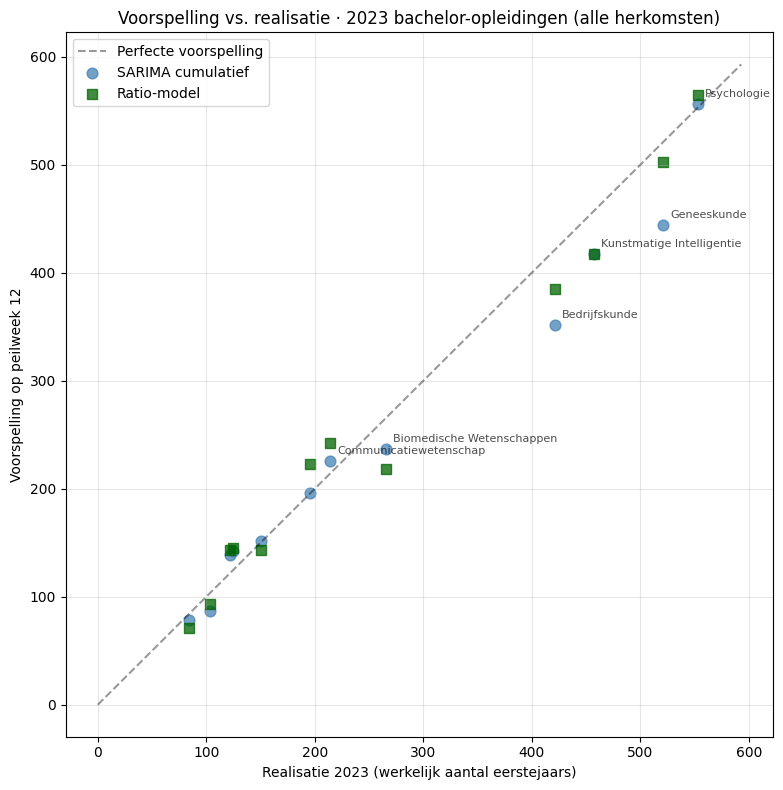

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

max_v = vergelijking[["Realisatie", "SARIMA_cumulative", "Prognose_ratio"]].max().max() * 1.05
ax.plot([0, max_v], [0, max_v], "k--", alpha=0.4, label="Perfecte voorspelling")
ax.scatter(vergelijking["Realisatie"], vergelijking["SARIMA_cumulative"],
           s=60, alpha=0.75, color="steelblue", label="SARIMA cumulatief")
ax.scatter(vergelijking["Realisatie"], vergelijking["Prognose_ratio"],
           s=60, alpha=0.75, color="darkgreen", marker="s", label="Ratio-model")

for _, row in vergelijking.iterrows():
    if row["Realisatie"] > 200:
        ax.annotate(row["Croho groepeernaam"].replace("B ", ""),
                    (row["Realisatie"], row["SARIMA_cumulative"]),
                    fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Realisatie 2023 (werkelijk aantal eerstejaars)")
ax.set_ylabel("Voorspelling op peilweek 12")
ax.set_title(f"Voorspelling vs. realisatie · {PREDICT_YEAR} bachelor-opleidingen (alle herkomsten)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 5. Samenvattende MAE en MAPE

De **MAE** (Mean Absolute Error) is de gemiddelde absolute afwijking in *aantal studenten*.
De **MAPE** (Mean Absolute Percentage Error) is hetzelfde maar in *%*, vergelijkbaar tussen
grote en kleine opleidingen.


In [6]:
samenvatting = pd.DataFrame({
    "Model": ["SARIMA cumulatief", "Ratio-model"],
    "MAE (studenten)": [
        vergelijking["MAE_SARIMA"].abs().mean().round(1),
        vergelijking["MAE_Ratio"].abs().mean().round(1),
    ],
    "MAPE (%)": [
        vergelijking["%_SARIMA"].abs().mean().round(1),
        vergelijking["%_Ratio"].abs().mean().round(1),
    ],
    "Aantal opleidingen": [len(vergelijking)] * 2,
})
samenvatting


,Model,MAE (studenten),MAPE (%),Aantal opleidingen
0,SARIMA cumulatief,24.0,9.0,12
1,Ratio-model,23.4,11.0,12


Prediction for B Bedrijfskunde, EER, year: 2023, week: 12
Prediction for B Filosofie, NL, year: 2023, week: 12
Prediction for B Kunstmatige Intelligentie, EER, year: 2023, week: 12
Prediction for B Psychologie, NL, year: 2023, week: 12
Prediction for M Bestuurskunde, Niet-EER, year: 2023, week: 12
Prediction for M Linguistiek, NL, year: 2023, week: 12
Prediction for B Bedrijfskunde, Niet-EER, year: 2023, week: 12
Prediction for B Geschiedenis, EER, year: 2023, week: 12
Prediction for B Natuurkunde, Niet-EER, year: 2023, week: 12
Prediction for B Scheikunde, NL, year: 2023, week: 12
Prediction for M Cognitive Neuroscience, EER, year: 2023, week: 12
Prediction for M Linguistiek, Niet-EER, year: 2023, week: 12
Prediction for B Biomedische Wetenschappen, NL, year: 2023, week: 12
Prediction for B Communicatiewetenschap, Niet-EER, year: 2023, week: 12
Prediction for B Geschiedenis, NL, year: 2023, week: 12
Prediction for B Politicologie, EER, year: 2023, week: 12
Prediction for B Scheikunde,

## 6. Conclusie en volgende stappen

Op deze demodata (Radboud 2023, peilweek 12) zien we:

- Beide modellen produceren een redelijke prognose, met **relatieve fouten van ±10–15%**.
- De **ratio-baseline** is verrassend competitief — een belangrijk signaal: de complexere
  modellen moeten dit *minstens* evenaren om hun complexiteit te rechtvaardigen.
- Een hogeschool zou hier per opleiding een eigen oordeel maken: voor stabiele
  opleidingen (vaste conversie) is het ratio-model voldoende; voor opleidingen met
  veranderend instroombeleid voegen SARIMA en XGBoost waarde toe.

| Wil je weten… | Open notebook |
|---------------|---------------|
| Of je eigen data correct geformatteerd is | `01_data_voorbereiden.ipynb` |
| Waarom de SARIMA-ordes vast staan | `02_sarima.ipynb` |
| Hoe de XGBoost-modellen werken | `03_xgboost.ipynb` |
| Wanneer het ratio-model voldoende is | `04_ratio_model.ipynb` |
| Hoe de modellen worden gecombineerd | `05_ensemble.ipynb` |
| Hoe je de Excel-output leest | `06_output_interpreteren.ipynb` |
